# dE/dx Simulation and Fit
Python port of `simulate_dEdx.C` (ROOT macro).

**Description:**
1. Simulates a `<dE/dx>` distribution for 100,000 tracks of various particle species (π, K, p, d) with specified multiplicities.
2. The `<dE/dx>` for each track is the 50% truncated mean of ionization points (L = 30–100), each sampled from a Landau distribution.
3. The Landau MPV is set from a tabulated Bethe-Bloch function.
4. Applies Gaussian smearing to simulate detector resolution.
5. Fits the resulting distributions for positive and negative particles separately using the full, track-length-dependent asymmetric Gaussian model.

## 1. Import Required Libraries

In [32]:
import os
os.environ['ROOT_WEBDISPLAY'] = 'off'

import ROOT
ROOT.PyConfig.IgnoreCommandLineOptions = True
ROOT.gROOT.SetBatch(True)

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import moyal   # Landau ≈ Moyal distribution
import warnings
warnings.filterwarnings('ignore')

rng = np.random.default_rng(42)
print("Imports OK. ROOT version:", ROOT.gROOT.GetVersion())

Imports OK. ROOT version: 6.32.06


## 2. Particle Species and Parameters

In [33]:
# --- Particle species ---
particle_names    = ["pi+", "pi-", "K+",    "K-",    "p+",    "p-",    "d+",    "anti-d-"]
particle_masses   = [0.13957, 0.13957, 0.49368, 0.49368, 0.93827, 0.93827, 1.8756, 1.8756]  # GeV/c^2
particle_charges  = [1, -1, 1, -1, 1, -1, 1, -1]

# Relative multiplicities (must sum to 1.0)
particle_mults = np.array([0.32, 0.30, 0.08, 0.04, 0.25, 0.01, 0.00, 0.00])
assert np.isclose(particle_mults.sum(), 1.0), "Multiplicities must sum to 1!"

cumulative_mults = np.cumsum(particle_mults)

# --- Simulation parameters ---
N_TRACKS       = 100_000
P              = 10.0     # GeV/c
MIN_LENGTH     = 30
MAX_LENGTH     = 100
TRUNC_FRACTION = 0.50     # 50% truncated mean
DETECTOR_RES   = 0.05     # 5% relative resolution (sigma/mean)

H_MIN, H_MAX, H_BINS = 0.7, 2.2, 200
bin_edges = np.linspace(H_MIN, H_MAX, H_BINS + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

## 3. Tabulated Bethe-Bloch Function

The tabulated Bethe-Bloch values (in MIP units) are interpolated as a function of $\beta\gamma = p/m$.
The table covers the range $\ln(\beta\gamma) \in [-1.011739,\, ...]$ with step $0.038083$.

In [34]:
BB_TABLE = np.array([
    6.4124, 6.0301, 5.6736, 5.3411, 5.0312, 4.7422, 4.4729, 4.2219,
    3.9880, 3.7701, 3.5671, 3.3781, 3.2020, 3.0382, 2.8857, 2.7437,
    2.6117, 2.4888, 2.3746, 2.2684, 2.1697, 2.0779, 1.9927, 1.9135,
    1.8400, 1.7718, 1.7086, 1.6499, 1.5954, 1.5450, 1.4983, 1.4550,
    1.4150, 1.3780, 1.3437, 1.3121, 1.2829, 1.2560, 1.2312, 1.2083,
    1.1873, 1.1680, 1.1502, 1.1339, 1.1190, 1.1053, 1.0929, 1.0815,
    1.0712, 1.0618, 1.0533, 1.0456, 1.0387, 1.0324, 1.0269, 1.0219,
    1.0176, 1.0137, 1.0103, 1.0074, 1.0049, 1.0028, 1.0011, 1.0000,
    1.0012, 1.0028, 1.0046, 1.0066, 1.0089, 1.0114, 1.0141, 1.0170,
    1.0201, 1.0234, 1.0268, 1.0303, 1.0340, 1.0378, 1.0418, 1.0458,
    1.0500, 1.0542, 1.0585, 1.0629, 1.0674, 1.0720, 1.0766, 1.0813,
    1.0860, 1.0908, 1.0957, 1.1006, 1.1055, 1.1105, 1.1155, 1.1206,
    1.1257, 1.1308, 1.1359, 1.1411, 1.1463, 1.1515, 1.1568, 1.1620,
    1.1673, 1.1726, 1.1779, 1.1832, 1.1886, 1.1939, 1.1993, 1.2047,
    1.2101, 1.2155, 1.2209, 1.2263, 1.2317, 1.2372, 1.2426, 1.2481,
    1.2535, 1.2590, 1.2644, 1.2699, 1.2753, 1.2807, 1.2860, 1.2912,
    1.2963, 1.3013, 1.3063, 1.3112, 1.3160, 1.3208, 1.3255, 1.3301,
    1.3346, 1.3391, 1.3435, 1.3478, 1.3521, 1.3563, 1.3604, 1.3644,
    1.3684, 1.3723, 1.3762, 1.3800, 1.3841, 1.3884, 1.3927, 1.3969,
    1.4011, 1.4052, 1.4092, 1.4129, 1.4167, 1.4203, 1.4239, 1.4275,
    1.4310, 1.4347, 1.4383, 1.4419, 1.4454, 1.4488, 1.4523, 1.4559,
    1.4595, 1.4630, 1.4664, 1.4698, 1.4731, 1.4762, 1.4792, 1.4821,
    1.4851, 1.4880, 1.4908, 1.4936, 1.4963, 1.4990, 1.5017, 1.5043,
    1.5069, 1.5093, 1.5116, 1.5140, 1.5163, 1.5185, 1.5207, 1.5229,
    1.5250, 1.5271, 1.5292, 1.5312, 1.5332, 1.5352, 1.5371, 1.5390,
    1.5408, 1.5427, 1.5445, 1.5462, 1.5479, 1.5496, 1.5513, 1.5529,
    1.5545, 1.5555, 1.5564, 1.5573, 1.5581, 1.5590, 1.5598, 1.5606,
    1.5613, 1.5620, 1.5627, 1.5634, 1.5641, 1.5647, 1.5653, 1.5659,
    1.5665, 1.5670, 1.5675, 1.5680, 1.5685, 1.5690, 1.5694, 1.5699,
    1.5703, 1.5706, 1.5710, 1.5714, 1.5717, 1.5720, 1.5723, 1.5726,
    1.5729, 1.5732, 1.5734, 1.5737, 1.5739, 1.5741, 1.5743, 1.5745,
    1.5746, 1.5748, 1.5750, 1.5751, 1.5752, 1.5754, 1.5755, 1.5756,
])

BB_N        = 256
BB_LNBG_MIN = -1.011739
BB_LNBG_STP =  0.038083

def tab_bethe_bloch(p, mass):
    """Return dE/dx in MIP units via table interpolation.
    
    Parameters
    ----------
    p    : momentum  [GeV/c]
    mass : rest mass [GeV/c^2]
    """
    if mass <= 0:
        return 0.0
    lnbg = np.log(p / mass)
    j = int((lnbg - BB_LNBG_MIN) / BB_LNBG_STP)
    j = max(0, min(j, BB_N - 2))
    dx = lnbg - (j * BB_LNBG_STP + BB_LNBG_MIN)
    return dx * (BB_TABLE[j + 1] - BB_TABLE[j]) / BB_LNBG_STP + BB_TABLE[j]

# Compute MPVs for all species at p = P
dedx_mpvs = {name: tab_bethe_bloch(P, m) for name, m in zip(particle_names, particle_masses)}
for name, mpv in dedx_mpvs.items():
    if particle_mults[particle_names.index(name)] > 0:
        print(f"  {name:10s}  MPV = {mpv:.4f} MIP")

  pi+         MPV = 1.3467 MIP
  pi-         MPV = 1.3467 MIP
  K+          MPV = 1.1756 MIP
  K-          MPV = 1.1756 MIP
  p+          MPV = 1.0894 MIP
  p-          MPV = 1.0894 MIP


## 4. Visualize Bethe-Bloch curves vs Momentum

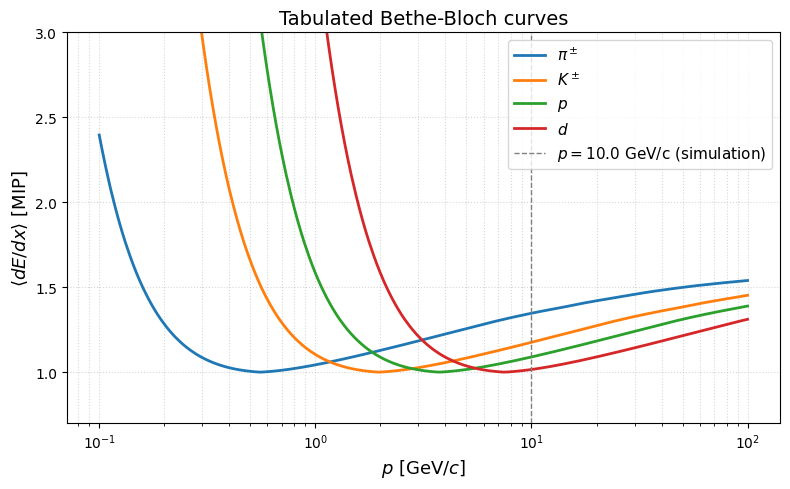

In [35]:
p_range = np.logspace(-1, 2, 400)  # 0.1 to 100 GeV/c

plot_species = [
    ("pi+",  0.13957, "C0", r"$\pi^\pm$"),
    ("K+",   0.49368, "C1", r"$K^\pm$"),
    ("p+",   0.93827, "C2", r"$p$"),
    ("d+",   1.8756,  "C3", r"$d$"),
]

fig, ax = plt.subplots(figsize=(8, 5))
for name, mass, color, label in plot_species:
    curve = [tab_bethe_bloch(pp, mass) for pp in p_range]
    ax.plot(p_range, curve, color=color, label=label, lw=2)

ax.axvline(P, color='grey', ls='--', lw=1, label=f"$p = {P}$ GeV/c (simulation)")
ax.set_xscale("log")
ax.set_xlabel(r"$p$ [GeV/$c$]", fontsize=13)
ax.set_ylabel(r"$\langle dE/dx \rangle$ [MIP]", fontsize=13)
ax.set_title("Tabulated Bethe-Bloch curves", fontsize=14)
ax.set_ylim(0.7,3)
ax.legend(fontsize=11)
ax.grid(True, which="both", ls=":", alpha=0.5)
plt.tight_layout()
plt.savefig("dedx_bethe_bloch.png", dpi=150)
plt.show()

## 5. Simulate dE/dx (Landau truncated mean + Gaussian smearing)

For each track:
1. Draw a particle species from the multiplicity distribution.
2. Draw a track length $L \in [30, 100]$ uniformly.
3. Sample $L$ ionization points from a Landau distribution with MPV given by Bethe-Bloch.
4. Sort and keep the lowest 50% (truncated mean).
5. Apply Gaussian smearing with relative width = `DETECTOR_RES`.

In [36]:
def landau_sample(rng, mpv, sigma, size):
    """Sample from a Landau distribution using the Moyal approximation (as in ROOT).
    Moyal is a good approximation to Landau for detector physics."""
    # scipy moyal: loc = mpv - sigma*(ln(2)+euler_gamma), scale = sigma
    # ROOT's TRandom::Landau uses a lookup table; we use Moyal as standard approximation.
    loc = mpv - sigma * (np.log(2) + 0.5772156649)
    return moyal.rvs(loc=loc, scale=sigma, size=size, random_state=rng)

# Storage
h_pos   = np.zeros(H_BINS)
h_neg   = np.zeros(H_BINS)
h_total = np.zeros(H_BINS)
h_species = {name: np.zeros(H_BINS) for name in particle_names}

print(f"Simulating {N_TRACKS:,} tracks...")

for i_track in range(N_TRACKS):
    if i_track % 10_000 == 0:
        print(f"  ... processed {i_track:,} tracks")

    # 1. Particle species
    r = rng.random()
    i_species = np.searchsorted(cumulative_mults, r)
    if i_species >= len(particle_names):
        continue
    name   = particle_names[i_species]
    mpv    = dedx_mpvs[name]
    charge = particle_charges[i_species]
    landau_sigma = 0.05 * mpv

    # 2. Track length
    L = int(rng.integers(MIN_LENGTH, MAX_LENGTH + 1))

    # 3. Ionization points from Landau
    pts = landau_sample(rng, mpv, landau_sigma, L)

    # 4. 50% truncated mean (keep lowest half)
    pts.sort()
    n_trunc = max(1, int(L * TRUNC_FRACTION))
    mean_dedx = pts[:n_trunc].mean()

    # 5. Gaussian smearing
    sigma_smear = mean_dedx * DETECTOR_RES
    smeared = rng.normal(mean_dedx, sigma_smear)

    # Fill histograms
    h_total  += np.histogram(smeared, bins=bin_edges)[0]
    h_species[name] += np.histogram(smeared, bins=bin_edges)[0]
    if charge > 0:
        h_pos += np.histogram(smeared, bins=bin_edges)[0]
    else:
        h_neg += np.histogram(smeared, bins=bin_edges)[0]

print("Simulation finished.")

Simulating 100,000 tracks...
  ... processed 0 tracks
  ... processed 10,000 tracks
  ... processed 20,000 tracks
  ... processed 30,000 tracks
  ... processed 40,000 tracks
  ... processed 50,000 tracks
  ... processed 60,000 tracks
  ... processed 70,000 tracks
  ... processed 80,000 tracks
  ... processed 90,000 tracks
Simulation finished.


## 6. Visualize Simulation Results

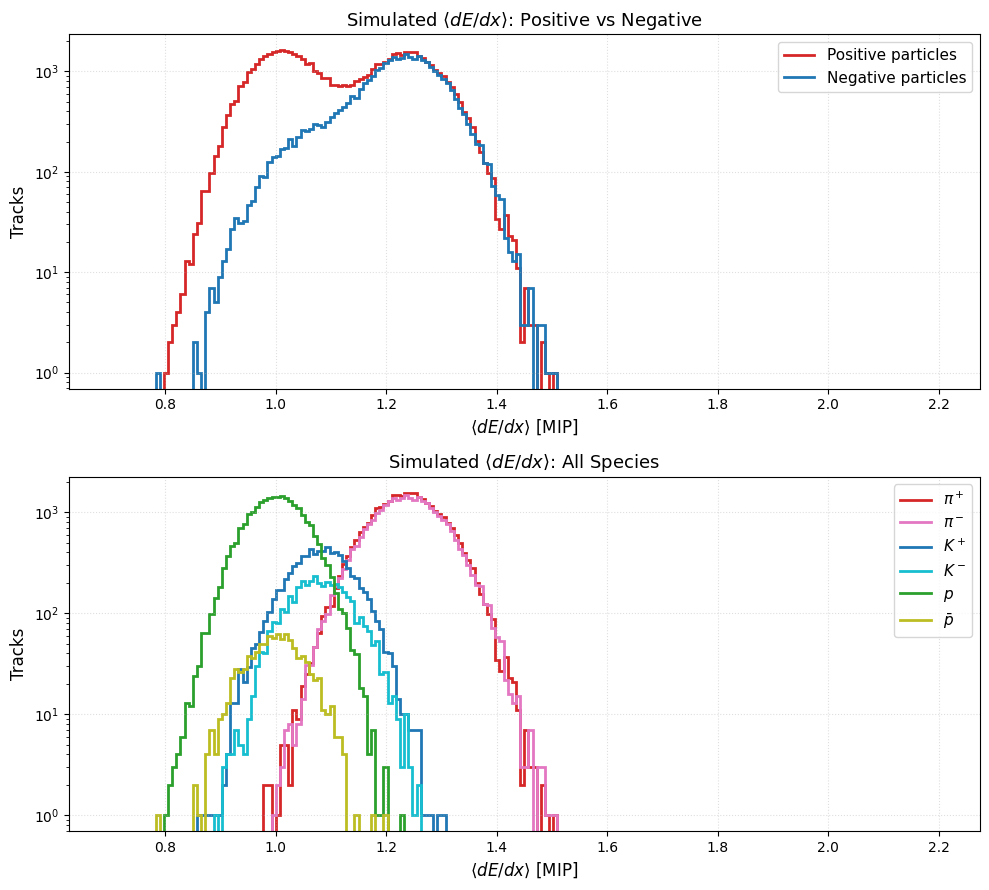

In [37]:
species_colors = {
    "pi+": "tab:red",    "pi-": "tab:pink",
    "K+":  "tab:blue",   "K-":  "tab:cyan",
    "p+":  "tab:green",  "p-":  "tab:olive",
    "d+":  "tab:purple", "anti-d-": "tab:gray",
}
species_labels = {
    "pi+": r"$\pi^+$", "pi-": r"$\pi^-$",
    "K+":  r"$K^+$",   "K-":  r"$K^-$",
    "p+":  r"$p$",     "p-":  r"$\bar{p}$",
    "d+":  r"$d$",     "anti-d-": r"$\bar{d}$",
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 9))

# --- Top: positive vs negative ---
ax1.stairs(h_pos, bin_edges, color="tab:red",  lw=2, label="Positive particles")
ax1.stairs(h_neg, bin_edges, color="tab:blue", lw=2, label="Negative particles")
ax1.set_yscale("log")
ax1.set_xlabel(r"$\langle dE/dx \rangle$ [MIP]", fontsize=12)
ax1.set_ylabel("Tracks", fontsize=12)
ax1.set_title(r"Simulated $\langle dE/dx \rangle$: Positive vs Negative", fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(True, ls=":", alpha=0.4)

# --- Bottom: per species ---
for name, hist in h_species.items():
    idx = particle_names.index(name)
    if particle_mults[idx] > 0:
        ax2.stairs(hist, bin_edges, color=species_colors[name], lw=2, label=species_labels[name])
ax2.set_yscale("log")
ax2.set_xlabel(r"$\langle dE/dx \rangle$ [MIP]", fontsize=12)
ax2.set_ylabel("Tracks", fontsize=12)
ax2.set_title(r"Simulated $\langle dE/dx \rangle$: All Species", fontsize=13)
ax2.legend(fontsize=11)
ax2.grid(True, ls=":", alpha=0.4)

plt.tight_layout()
plt.savefig(f"dEdx_simulation_{DETECTOR_RES:.2f}.png", dpi=150)
plt.savefig(f"dEdx_simulation_{DETECTOR_RES:.2f}.pdf")
plt.show()

## 7. Fit Model: Track-Length-Averaged Asymmetric Gaussian

The fit uses **iminuit** — a Python binding to ROOT's **Minuit2** C++ minimiser — with a chi-squared cost function on the binned histogram.

For each particle species $s$ with amplitude $N_s$ and mean position $x_s$, the contribution is:

$$
f_s(x) = \frac{N_s}{n_L} \sum_{l=l_{\min}}^{l_{\max}}
  \frac{1}{\sqrt{2\pi}\,\sigma_s(l)}\,
  \exp\left[-\frac{1}{2}\left(\frac{x - x_s + \delta_l \cdot \sigma_s(l) \cdot \frac{2}{\sqrt{2\pi}}}{\sigma_s(l)(1+\delta_l)}\right)^{2}\right]
$$

where:
- $\sigma_s(l) = \frac{\sigma_0}{\sqrt{l}} \left(\frac{x_s}{x_\pi}\right)^\alpha$ — width scaling with track length and dE/dx
- $\delta_l = \delta_0 / l$ — per-length asymmetry parameter

**Parameters (11 total, 2 fixed):**
`[N_pi, N_K, N_p, N_d*, x_pi, r_K, r_p, r_d*, sigma_0, alpha, delta_0]`
(*fixed: deuteron amplitude and ratio are fixed to zero / Bethe-Bloch prediction since no deuterons are simulated)

In [38]:
L_RANGE = np.arange(MIN_LENGTH, MAX_LENGTH + 1, dtype=float)
N_L     = len(L_RANGE)
SQRT_L  = np.sqrt(L_RANGE)

SQRT2PI      = np.sqrt(2.0 * np.pi)
SHIFT_FACTOR = 2.0 / SQRT2PI

def _component_sum(x_arr, N, x_s, x_pi, sigma_0, alpha, delta_0):
    if N == 0.0:
        return np.zeros_like(x_arr)
    sigma_l = (sigma_0 / SQRT_L) * (x_s / x_pi) ** alpha
    delta_l = delta_0 / L_RANGE
    width_l = (1.0 + delta_l) * sigma_l
    shift_l = SHIFT_FACTOR * delta_l * sigma_l
    norm_l  = 1.0 / (SQRT2PI * sigma_l)
    arg   = (x_arr[:, None] - x_s + shift_l[None, :]) / width_l[None, :]
    gauss = norm_l[None, :] * np.exp(-0.5 * arg ** 2)
    return N * gauss.sum(axis=1) / N_L

def fit_func_np(x_arr, N_pi, N_K, N_p, N_d, x_pi, r_K, r_p, r_d, sigma_0, alpha, delta_0):
    """Vectorised numpy model — used for plotting component curves."""
    x_K = x_pi * r_K;  x_p = x_pi * r_p;  x_d = x_pi * r_d
    return (
        _component_sum(x_arr, N_pi, x_pi, x_pi, sigma_0, alpha, delta_0) +
        _component_sum(x_arr, N_K,  x_K,  x_pi, sigma_0, alpha, delta_0) +
        _component_sum(x_arr, N_p,  x_p,  x_pi, sigma_0, alpha, delta_0) +
        _component_sum(x_arr, N_d,  x_d,  x_pi, sigma_0, alpha, delta_0)
    )

def make_tf1_func(name):
    """Wrap fit_func_np into a ROOT TF1-compatible scalar callable."""
    def f(x, par):
        val = np.array([x[0]])
        return float(fit_func_np(val,
            par[0], par[1], par[2], par[3],
            par[4], par[5], par[6], par[7],
            par[8], par[9], par[10])[0])
    f.__name__ = name
    return f

def numpy_to_th1d(name, values, edges):
    """Convert a numpy histogram to ROOT TH1D with Poisson errors."""
    h = ROOT.TH1D(name, name, len(values), edges[0], edges[-1])
    h.Sumw2()
    for i, v in enumerate(values):
        h.SetBinContent(i + 1, float(v))
        h.SetBinError(i + 1, float(np.sqrt(v)) if v > 0 else 1.0)
    return h

bin_width = bin_edges[1] - bin_edges[0]
norm_pos  = h_pos.sum() * bin_width
norm_neg  = h_neg.sum() * bin_width
l_mean    = (MIN_LENGTH + MAX_LENGTH) / 2.0

print("Fit model ready.")

Fit model ready.


## 8. Fit Positive Particles

In [39]:
x_pi_pos_init = bin_centers[np.argmax(h_pos)]
pi_rms_pos    = np.sqrt(np.average((bin_centers - x_pi_pos_init)**2, weights=h_pos + 1e-9))

# Build ROOT histogram
h_pos_root = numpy_to_th1d("h_pos_root", h_pos, bin_edges)

# Build TF1 from the Python model
tf1_pos = ROOT.TF1("fPos", make_tf1_func("fPos"), H_MIN, H_MAX, 11)
tf1_pos.SetNpx(500)

param_names_pos = ["N_pi+", "N_K+", "N_p+", "N_d+",
                   "x_pi+", "r_K",  "r_p",  "r_d",
                   "sigma_0", "alpha", "delta_0"]
for i, n in enumerate(param_names_pos):
    tf1_pos.SetParName(i, n)

tf1_pos.SetParameter(0, norm_pos * particle_mults[0])
tf1_pos.SetParameter(1, norm_pos * particle_mults[2])
tf1_pos.SetParameter(2, norm_pos * particle_mults[4])
tf1_pos.FixParameter(3, 0.0)                                      # N_d+ fixed
tf1_pos.SetParameter(4, dedx_mpvs["pi+"])
tf1_pos.SetParLimits(4, dedx_mpvs["pi+"] * 0.8, dedx_mpvs["pi+"] * 1.2)
tf1_pos.SetParameter(5, dedx_mpvs["K+"]  / dedx_mpvs["pi+"])
tf1_pos.SetParameter(6, dedx_mpvs["p+"]  / dedx_mpvs["pi+"])
tf1_pos.FixParameter(7, dedx_mpvs["d+"]  / dedx_mpvs["pi+"])     # r_d fixed
tf1_pos.SetParameter(8, pi_rms_pos * np.sqrt(l_mean))
tf1_pos.SetParLimits(8, 1e-6, 10.0)
tf1_pos.SetParameter(9, 0.1)
tf1_pos.SetParameter(10, 0.1)

print("Fitting positive particles with ROOT TF1/Minuit ...")
fit_res_pos = h_pos_root.Fit(tf1_pos, "RSQ")   # R=range, S=return FitResult, Q=quiet

print(f"Fit status: {int(fit_res_pos.Status())}   "
      f"chi2/ndf = {tf1_pos.GetChisquare():.2f} / {tf1_pos.GetNDF()}")
print("\nFitted parameters (positive):")
for i, n in enumerate(param_names_pos):
    print(f"  {n:<10s} = {tf1_pos.GetParameter(i):10.4f}  ±  {tf1_pos.GetParError(i):.4f}")

popt_pos = [tf1_pos.GetParameter(i) for i in range(11)]

Fitting positive particles with ROOT TF1/Minuit ...
Fit status: 0   chi2/ndf = 219.82 / 191

Fitted parameters (positive):
  N_pi+      =   149.1213  ±  5.9330
  N_K+       =   255.4911  ±  11.6508
  N_p+       =   363.3055  ±  8.8354
  N_d+       =     0.0000  ±  0.0000
  x_pi+      =     1.2018  ±  0.0065
  r_K        =     1.0000  ±  0.0074
  r_p        =     0.8227  ±  0.0039
  r_d        =     0.7542  ±  0.0000
  sigma_0    =     0.8151  ±  0.0256
  alpha      =     0.9389  ±  0.0942
  delta_0    =   -21.3387  ±  1.0796


Warning in <TROOT::Append>: Replacing existing TH1: h_pos_root (Potential memory leak).


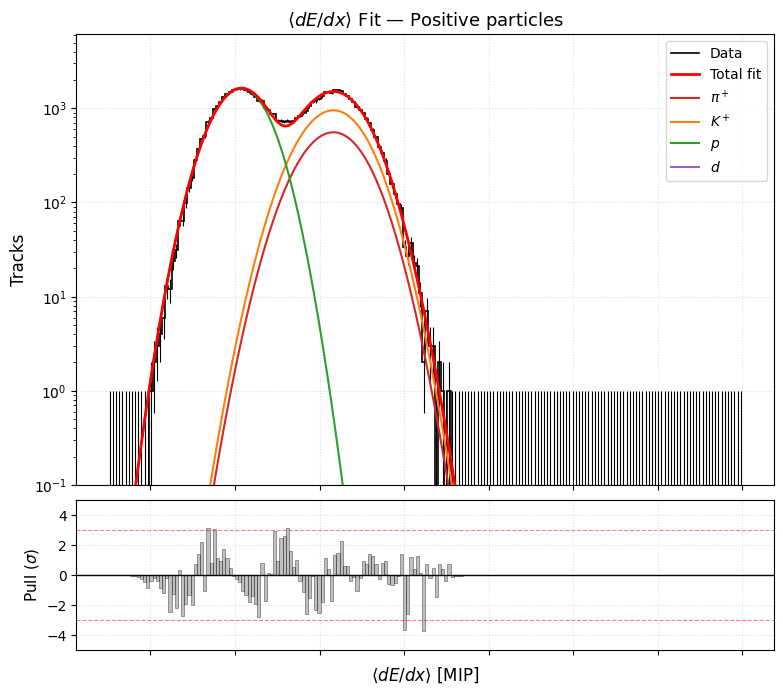

In [40]:
comp_labels_pos   = [r"$\pi^+$", r"$K^+$", r"$p$", r"$d$"]
comp_labels_neg   = [r"$\pi^-$", r"$K^-$", r"$\bar{p}$", r"$\bar{d}$"]
comp_colors_specs = ["tab:red", "tab:orange", "tab:green", "tab:purple"]


def plot_fit_with_pulls(hist, bin_edges, popt, title, comp_labels, comp_colors, save_name):
    """Plot histogram data + ROOT-fitted total curve + per-species components + Pulls."""
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    err = np.where(hist > 0, np.sqrt(hist), 1.0)
    
    # Calculate model and pulls
    y_model = fit_func_np(bin_centers, *popt)
    pulls = (hist - y_model) / err

    fig = plt.figure(figsize=(9, 8))
    gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.05)
    
    # --- Top: Fit Plot ---
    ax_main = fig.add_subplot(gs[0])
    ax_main.stairs(hist, bin_edges, color="black", lw=1.2, label="Data", zorder=3)
    ax_main.errorbar(bin_centers, hist, yerr=err,
                fmt='none', ecolor='black', elinewidth=0.8, capsize=0, zorder=4)

    x_fine = np.linspace(bin_edges[0], bin_edges[-1], 1000)
    ax_main.plot(x_fine, fit_func_np(x_fine, *popt), 'r-', lw=2, label="Total fit", zorder=5)

    for i in range(4):
        p_c = list(popt)
        for j in range(4):
            if j != i:
                p_c[j] = 0.0
        ax_main.plot(x_fine, fit_func_np(x_fine, *p_c), '-',
                color=comp_colors[i], lw=1.5, label=comp_labels[i], zorder=4)

    ax_main.set_yscale("log")
    ax_main.set_ylabel("Tracks", fontsize=12)
    ax_main.set_title(title, fontsize=13)
    ax_main.legend(fontsize=10)
    ax_main.grid(True, ls=":", alpha=0.4)
    ax_main.set_ylim(1e-1, h_total.max() * 2)
    ax_main.set_xticklabels([]) # Hide x-labels for top panel

    # --- Bottom: Pulls Plot ---
    ax_pull = fig.add_subplot(gs[1], sharex=ax_main)
    ax_pull.bar(bin_centers, pulls, width=np.diff(bin_edges), color='gray', alpha=0.5, edgecolor='black', lw=0.5)
    ax_pull.axhline(0, color='black', lw=1)
    ax_pull.axhline(3, color='red', ls='--', lw=0.8, alpha=0.5)
    ax_pull.axhline(-3, color='red', ls='--', lw=0.8, alpha=0.5)
    
    ax_pull.set_ylabel(r"Pull ($\sigma$)", fontsize=11)
    ax_pull.set_xlabel(r"$\langle dE/dx \rangle$ [MIP]", fontsize=12)
    ax_pull.set_ylim(-5, 5)
    ax_pull.grid(True, ls=":", alpha=0.4)

    plt.tight_layout()
    plt.savefig(f"{save_name}.png", dpi=150)
    plt.savefig(f"{save_name}.pdf")
    plt.show()


plot_fit_with_pulls(h_pos, bin_edges, popt_pos,
                   r"$\langle dE/dx \rangle$ Fit — Positive particles",
                   comp_labels_pos, comp_colors_specs,
                   f"dEdx_fit_positive_{DETECTOR_RES:.2f}")

## 9. Fit Negative Particles

Fitting negative particles with ROOT TF1/Minuit ...
Fit status: 4000   chi2/ndf = 120.70 / 191

Fitted parameters (negative):
  N_pi-      =    93.0199  ±  24.4865
  N_K-       =   150.6949  ±  21.6469
  N_p-       =    43.6128  ±  3.1635
  N_d-bar    =     0.0000  ±  0.0000
  x_pi-      =     1.2715  ±  0.0086
  r_K        =     0.9534  ±  0.0029
  r_p        =     0.8380  ±  0.0032
  r_d        =     0.7542  ±  0.0000
  sigma_0    =     0.4565  ±  0.0161
  alpha      =    -1.2032  ±  0.3290
  delta_0    =    -5.0000  ±  0.3970


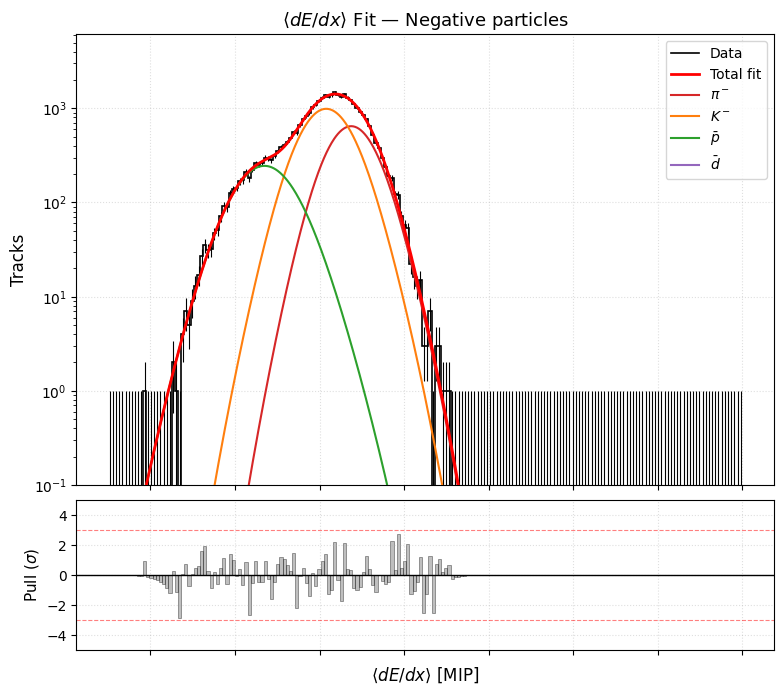


Done. Output files saved.


Warning in <TROOT::Append>: Replacing existing TH1: h_neg_root (Potential memory leak).


In [41]:
x_pi_neg_init = bin_centers[np.argmax(h_neg)]
pi_rms_neg    = np.sqrt(np.average((bin_centers - x_pi_neg_init)**2, weights=h_neg + 1e-9))

# Build ROOT histogram
h_neg_root = numpy_to_th1d("h_neg_root", h_neg, bin_edges)

# Build TF1 from the Python model
tf1_neg = ROOT.TF1("fNeg", make_tf1_func("fNeg"), H_MIN, H_MAX, 11)
tf1_neg.SetNpx(500)

param_names_neg = ["N_pi-", "N_K-", "N_p-", "N_d-bar",
                   "x_pi-", "r_K",  "r_p",  "r_d",
                   "sigma_0", "alpha", "delta_0"]
for i, n in enumerate(param_names_neg):
    tf1_neg.SetParName(i, n)

# --- Improved Initialization ---
# Amplitudes: use (hist integral * bin_width * multiplicity)
tf1_neg.SetParameter(0, norm_neg * particle_mults[1]) # pi-
tf1_neg.SetParameter(1, norm_neg * particle_mults[3]) # K-
tf1_neg.SetParameter(2, norm_neg * particle_mults[5]) # p-bar
tf1_neg.FixParameter(3, 0.0)                         # anti-d fixed to 0

# Means: Pion mass is 139.57 MeV
tf1_neg.SetParameter(4, x_pi_neg_init)
tf1_neg.SetParLimits(4, x_pi_neg_init * 0.95, x_pi_neg_init * 1.05)

# Ratios: Set from BB table
tf1_neg.SetParameter(5, dedx_mpvs["K-"] / dedx_mpvs["pi-"])
tf1_neg.SetParameter(6, dedx_mpvs["p-"] / dedx_mpvs["pi-"])
tf1_neg.FixParameter(7, dedx_mpvs["anti-d-"] / dedx_mpvs["pi-"])

# Resolution and Asymmetry
tf1_neg.SetParameter(8, DETECTOR_RES * x_pi_neg_init * np.sqrt(l_mean)) # sigma_0
tf1_neg.SetParLimits(8, 0.01, 2.0)
tf1_neg.SetParameter(9, 0.1)  # alpha
tf1_neg.SetParLimits(9, -1.5, 1.5)
tf1_neg.SetParameter(10, 0.5) # delta_0 (positive asymmetry)
tf1_neg.SetParLimits(10, -5.0, 5.0)

print("Fitting negative particles with ROOT TF1/Minuit ...")
# Perform fit with multiple strategies if needed
h_neg_root.Fit(tf1_neg, "RLQM") # L=Likelihood (often better), M=Improve
fit_res_neg = h_neg_root.Fit(tf1_neg, "RSQM") # Final fit with S=Result

print(f"Fit status: {int(fit_res_neg.Status())}   "
      f"chi2/ndf = {tf1_neg.GetChisquare():.2f} / {tf1_neg.GetNDF()}")
print("\nFitted parameters (negative):")
for i, n in enumerate(param_names_neg):
    print(f"  {n:<10s} = {tf1_neg.GetParameter(i):10.4f}  ±  {tf1_neg.GetParError(i):.4f}")

popt_neg = [tf1_neg.GetParameter(i) for i in range(11)]

# --- Plot with Pulls ---
plot_fit_with_pulls(h_neg, bin_edges, popt_neg,
                   r"$\langle dE/dx \rangle$ Fit — Negative particles",
                   comp_labels_neg, comp_colors_specs,
                   f"dEdx_fit_negative_{DETECTOR_RES:.2f}")

print("\nDone. Output files saved.")